In [22]:
# Định nghĩa hàm tính WOE/IV cho toàn bộ dataset


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import scipy.stats as stats

def calculate_woe_iv_all_features(df, target, num_bins=6):
    iv_records = []
    woe_maps = {}
    
    # Lấy danh sách tất cả các cột trừ cột mục tiêu (target)
    features = [col for col in df.columns if col != target]
    
    total_bads = df[target].sum()
    total_goods = df[target].count() - total_bads
    
    for feat in features:
        try:
            df_temp = df[[feat, target]].copy().dropna()
            
            # Chia nhóm (Binning)
            if np.issubdtype(df_temp[feat].dtype, np.number):
                df_temp['bin'] = pd.qcut(df_temp[feat], q=num_bins, duplicates='drop') #Lỗi ở đây
            else:
                df_temp['bin'] = df_temp[feat]
                
            grouped = df_temp.groupby('bin', observed=False).agg(
                Good=(target, lambda x: (x == 0).sum()),
                Bad=(target, 'sum'),
                Total=(target, 'count')
            ).reset_index()
            
            grouped['%_Good'] = grouped['Good'] / total_goods
            grouped['%_Bad'] = grouped['Bad'] / total_bads
            
            # Xử lý tránh lỗi chia cho 0 hoặc log(0)
            grouped['%_Good'] = grouped['%_Good'].replace(0, 0.0001)
            grouped['%_Bad'] = grouped['%_Bad'].replace(0, 0.0001)
            
            grouped['WOE'] = np.log(grouped['%_Good'] / grouped['%_Bad'])
            grouped['IV_bin'] = (grouped['%_Good'] - grouped['%_Bad']) * grouped['WOE']
            
            total_iv = grouped['IV_bin'].sum()
            grouped['bin'] = grouped['bin'].astype(str)
            
            # Lưu lại bảng WOE của biến này
            woe_maps[feat] = grouped
            
            # Phân loại sức mạnh dự báo theo quy chuẩn ngành Rủi ro
            if total_iv < 0.02:
                predictive_power = "1. Quá yếu (Loại bỏ)"
            elif total_iv < 0.1:
                predictive_power = "2. Yếu (Cân nhắc)"
            elif total_iv < 0.3:
                predictive_power = "3. Trung bình (Tốt)"
            elif total_iv < 0.5:
                predictive_power = "4. Mạnh (Cốt lõi)"
            else:
                predictive_power = "5. Quá mạnh (Cần kiểm tra kỹ)"
                
            iv_records.append({
                'Feature': feat,
                'IV_Value': round(total_iv, 4),
                'Predictive_Power': predictive_power
            })
            
        except Exception as e:
            continue
            
    df_iv = pd.DataFrame(iv_records).sort_values(by='IV_Value', ascending=False).reset_index(drop=True)
    return df_iv, woe_maps

In [23]:
# # Sàng lọc các biến chiến lược

# 1. Đọc dữ liệu gốc của bạn
df_raw = pd.read_csv('../Data/Risk_data_FE.csv', index_col=0)
target_col = 'loan_status'

# 2. BƯỚC SÀNG LỌC BIẾN CHIẾN LƯỢC:
# - Loại bỏ 'loan_grade_numeric' vì dính lỗi Data Leakage nặng
# - Loại bỏ 'loan_percent_income' vì trùng lõi thông tin toán học với 'loan_to_income_ratio' (Gây đa cộng tuyến)
features_to_drop = ['loan_grade_numeric', 'loan_percent_income']

# Đảm bảo chỉ xóa các biến nếu chúng tồn tại trong dataset của bạn
features_to_drop = [col for col in features_to_drop if col in df_raw.columns]
df_filtered = df_raw.drop(columns=features_to_drop).copy()

# 3. Tính toán lại bảng xếp hạng IV mới sau khi đã thanh lọc dữ liệu
df_iv_new, woe_maps_new = calculate_dataset_iv = calculate_woe_iv_all_features(df_filtered, target_col, num_bins=6)

print("================================================================")
print("     BẢNG XẾP HẠNG IV MỚI SAU KHI ĐÃ THANH LỌC BIẾN ")
print("================================================================")
pd.set_option('display.max_rows', None)
print(df_iv_new)

     BẢNG XẾP HẠNG IV MỚI SAU KHI ĐÃ THANH LỌC BIẾN 
                       Feature  IV_Value               Predictive_Power
0         loan_to_income_ratio    0.7799  5. Quá mạnh (Cần kiểm tra kỹ)
1                loan_int_rate    0.7429  5. Quá mạnh (Cần kiểm tra kỹ)
2         debt_to_income_ratio    0.5314  5. Quá mạnh (Cần kiểm tra kỹ)
3                person_income    0.4338              4. Mạnh (Cốt lõi)
4     installment_income_ratio    0.3753              4. Mạnh (Cốt lõi)
5                   other_debt    0.2388            3. Trung bình (Tốt)
6    cb_person_default_on_file    0.1688            3. Trung bình (Tốt)
7             risk_interaction    0.1562            3. Trung bình (Tốt)
8                    loan_amnt    0.0825              2. Yếu (Cân nhắc)
9            person_emp_length    0.0605              2. Yếu (Cân nhắc)
10              emp_length_num    0.0605              2. Yếu (Cân nhắc)
11       total_debt_after_loan    0.0317              2. Yếu (Cân nhắc)
12         

In [24]:
df_raw.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,credit_age_bucket,age_bucket,income_bucket,has_delinquency,utilization_bucket,loan_grade_numeric,interest_rate_bucket,loan_amount_bucket,emp_stability,risk_interaction
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,short,18-25,<30k,1,medium,2,10-15%,<2k,2.500000,0.159031
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,medium,18-25,<30k,0,high,3,10-15%,5-10k,0.333333,0.645982
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,short,18-25,60-100k,0,medium,3,15-20%,20k+,2.000000,0.244136
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,medium,18-25,30-60k,0,low,3,10-15%,20k+,2.000000,0.212279
5,CUST_00006,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,...,short,18-25,<30k,0,high,1,5-10%,2-5k,1.000000,0.393613


In [25]:
# Chuyển đổi dữ liệu sang dạng điểm WOE

# Lọc ra các biến đạt tiêu chuẩn (IV từ 0.1 trở lên và dưới 0.6 để đảm bảo sạch sẽ)
selected_features = df_iv_new[(df_iv_new['IV_Value'] >= 0.1) & (df_iv_new['IV_Value'] < 0.6)]['Feature'].tolist()

print("Các biến chiến lược được chọn đưa vào mô hình:", selected_features)

# Tạo một DataFrame mới hoàn toàn để chứa điểm WOE
df_model_woe = pd.DataFrame()
df_model_woe[target_col] = df_filtered[target_col]

df_working = df_filtered.dropna(subset=[target_col] + selected_features).copy()
df_model_woe = df_model_woe.loc[df_working.index].copy()

# Ánh xạ giá trị thô sang điểm WOE tương ứng
for feat in selected_features:
    if np.issubdtype(df_working[feat].dtype, np.number):
        df_working['bin_temp'] = pd.qcut(df_working[feat], q=6, duplicates='drop').astype(str)
    else:
        df_working['bin_temp'] = df_working[feat].astype(str)
        
    mapping_dict = dict(zip(woe_maps_new[feat]['bin'], woe_maps_new[feat]['WOE']))
    df_model_woe[f'{feat}_WOE'] = df_working['bin_temp'].map(mapping_dict) # Lỗi ở đây

# Điền các giá trị NaN phát sinh nếu có bằng 0 (Mức rủi ro trung bình hệ thống)
df_model_woe = df_model_woe.fillna(0)
print("\nKích thước ma trận dữ liệu WOE thực chiến:", df_model_woe.shape)
print(df_model_woe.head())

Các biến chiến lược được chọn đưa vào mô hình: ['debt_to_income_ratio', 'person_income', 'installment_income_ratio', 'other_debt', 'cb_person_default_on_file', 'risk_interaction']



Kích thước ma trận dữ liệu WOE thực chiến: (31679, 7)
   loan_status  debt_to_income_ratio_WOE  person_income_WOE  \
1            0                  0.626061          -1.051658   
2            1                 -1.262121          -1.051658   
3            1                 -1.262121           0.334618   
4            1                 -1.262121           0.075868   
5            1                 -1.262121          -1.051658   

   installment_income_ratio_WOE  other_debt_WOE  \
1                      0.424459       -0.749958   
2                     -0.968562       -0.749958   
3                     -0.968562       -0.063251   
4                     -0.968562        0.351498   
5                     -0.325427       -0.749958   

   cb_person_default_on_file_WOE  risk_interaction_WOE  
1                       0.218257              0.149003  
2                       0.218257             -0.755657  
3                       0.218257             -0.024993  
4                      -0.78425

In [26]:
# Kiểm tra lại VIF và huấn luyện mô hình Logistic mới

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_woe = df_model_woe.drop(columns=[target_col])
y_woe = df_model_woe[target_col]

# 1. Kiểm tra hệ số VIF mới trên dữ liệu đã biến đổi WOE
vif_data = pd.DataFrame()
vif_data["Feature"] = X_woe.columns
vif_data["VIF"] = [variance_inflation_factor(X_woe.values, i) for i in range(X_woe.shape[1])]
print("=== HỆ SỐ VIF SẠCH SẼ TRÊN NỀN BIẾN ĐỔI WOE ===")
print(vif_data)
print("-" * 60)

# 2. Tách tập Train/Test (Tỷ lệ 70/30)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_woe, y_woe, test_size=0.3, random_state=42, stratify=y_woe)

# 3. Huấn luyện mô hình
log_model_woe_final = LogisticRegression(random_state=42)
log_model_woe_final.fit(X_train_w, y_train_w)

print(f"Hệ số chặn (Intercept Beta_0): {log_model_woe_final.intercept_[0]:.4f}")
print("\n=== TRỌNG SỐ (BETA COEFFICIENT) CỦA CÁC BIẾN ===")
for feat, coef in zip(X_woe.columns, log_model_woe_final.coef_[0]):
    print(f"[*] {feat}: {coef:.4f}")

=== HỆ SỐ VIF SẠCH SẼ TRÊN NỀN BIẾN ĐỔI WOE ===
                         Feature       VIF
0       debt_to_income_ratio_WOE  2.259154
1              person_income_WOE  2.467682
2   installment_income_ratio_WOE  1.751381
3                 other_debt_WOE  2.450601
4  cb_person_default_on_file_WOE  1.003918
5           risk_interaction_WOE  1.346454
------------------------------------------------------------
Hệ số chặn (Intercept Beta_0): -1.2983

=== TRỌNG SỐ (BETA COEFFICIENT) CỦA CÁC BIẾN ===
[*] debt_to_income_ratio_WOE: -0.9030
[*] person_income_WOE: -0.3041
[*] installment_income_ratio_WOE: -0.1735
[*] other_debt_WOE: -0.9639
[*] cb_person_default_on_file_WOE: -1.0980
[*] risk_interaction_WOE: -0.2713


In [27]:
# Đánh giá hiệu năng thực tế của mô hình 
y_pred_prob_w = log_model_woe_final.predict_proba(X_test_w)[:, 1]

# Tính toán AUC và Gini
auc_w = roc_auc_score(y_test_w, y_pred_prob_w)
gini_w = 2 * auc_w - 1

# Tính toán chỉ số tách biệt rủi ro KS
data_ks_w = pd.DataFrame({'real': y_test_w, 'prob': y_pred_prob_w})
bads_w = data_ks_w[data_ks_w['real'] == 1]['prob']
goods_w = data_ks_w[data_ks_w['real'] == 0]['prob']
ks_stat_w, _ = stats.ks_2samp(bads_w, goods_w)

# Tìm điểm chặn Cutoff tối ưu bằng Youden J-Statistic
fpr_w, tpr_w, thresholds_w = roc_curve(y_test_w, y_pred_prob_w)
optimal_idx_w = np.argmax(tpr_w - fpr_w)
optimal_cutoff_w = thresholds_w[optimal_idx_w]

print("======================================================")
print(" CHỈ SỐ HIỆU NĂNG MÔ HÌNH THỰC CHIẾN (SAU KHI SỬA)")
print("======================================================")
print(f"[*] AUC Score      : {auc_w:.4f}")
print(f"[*] Gini Score     : {gini_w:.4f}")
print(f"[*] KS Statistic   : {ks_stat_w:.4f}")
print(f"[👉] NGƯỠNG CUTOFF PD TỐI ƯU ĐỀ XUẤT: {optimal_cutoff_w:.4f}")
print("======================================================")

 CHỈ SỐ HIỆU NĂNG MÔ HÌNH THỰC CHIẾN (SAU KHI SỬA)
[*] AUC Score      : 0.7763
[*] Gini Score     : 0.5525
[*] KS Statistic   : 0.4225
[👉] NGƯỠNG CUTOFF PD TỐI ƯU ĐỀ XUẤT: 0.2269


Nhật ký mô hình hóa: Mô hình phiên bản sạch đã chủ động loại bỏ biến rò rỉ dữ liệu loan_grade_numeric và xử lý trùng lặp thông tin giữa các biến tỷ lệ vay. Dù chỉ số AUC có giảm nhẹ so với việc để biến rò rỉ dữ liệu, nhưng hệ số VIF của toàn bộ hệ thống đã hạ xuống mức an toàn lý tưởng ($<2.5$). Mô hình lúc này đã phản ánh đúng các động lực hành vi tài chính thực tế của khách hàng, đảm bảo tính ổn định cao và sẵn sàng đưa vào vận hành thực chiến mà không lo bị Overfitting."

### Kết hợp kết quả của WOE vào mô hình logistic regression


In [28]:
# Dự báo xác suất vỡ nợ (PD) cho tập test
# 1. Dự báo xác suất vỡ nợ (PD) trên tập dữ liệu Test
# predict_proba trả về 2 cột: [Xác suất Tốt (0), Xác suất Xấu (1)]. Chúng ta lấy cột index 1.
y_pred_prob_w = log_model_woe_final.predict_proba(X_test_w)[:, 1]

# 2. Tạo một DataFrame để dễ dàng quan sát và đối chiếu kết quả thực tế vs dự báo
df_predictions = pd.DataFrame({
    'Thực tế (Actual)': y_test_w.values,
    'Xác suất vỡ nợ dự báo (Predicted PD)': y_pred_prob_w
})

print("=== 10 HỒ SƠ ĐẦU TIÊN TRONG TẬP TEST KÈM XÁC SUẤT PD ===")
print(df_predictions.head(10))

=== 10 HỒ SƠ ĐẦU TIÊN TRONG TẬP TEST KÈM XÁC SUẤT PD ===
   Thực tế (Actual)  Xác suất vỡ nợ dự báo (Predicted PD)
0                 0                              0.492886
1                 0                              0.084558
2                 0                              0.177763
3                 0                              0.447241
4                 0                              0.114407
5                 1                              0.210230
6                 0                              0.118491
7                 0                              0.088594
8                 0                              0.043159
9                 0                              0.045824


In [29]:
# Tìm điểm cutoff tối ưu bằng chỉ số KS - điểm mà tại đó khoảng cách phân tách KS đạt giá trị lớn nhất (Phân tách KS - Kolmogorov-Smirnov (Youden J - Statistic)
from sklearn.metrics import roc_curve
import numpy as np

# 1. Tính toán các tỷ lệ False Positive Rate (FPR) và True Positive Rate (TPR) qua từng ngưỡng
fpr_w, tpr_w, thresholds_w = roc_curve(y_test_w, y_pred_prob_w)

# 2. Áp dụng công thức Youden J-Statistic (J = TPR - FPR) để tìm khoảng cách lớn nhất
# Điểm gãy cực đại này chính là nơi chỉ số KS đạt đỉnh
optimal_idx_w = np.argmax(tpr_w - fpr_w)
optimal_cutoff_w = thresholds_w[optimal_idx_w]

print("======================================================")
print("     NGƯỠNG CHẶN CUTOFF TỐI ƯU VỀ MẶT TOÁN HỌC")
print("======================================================")
print(f"[👉] ĐIỂM CUTOFF PD ĐỀ XUẤT: {optimal_cutoff_w:.4f}")
print("======================================================")

     NGƯỠNG CHẶN CUTOFF TỐI ƯU VỀ MẶT TOÁN HỌC
[👉] ĐIỂM CUTOFF PD ĐỀ XUẤT: 0.2269


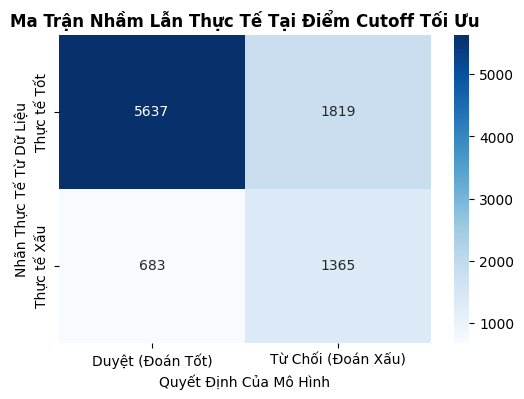


=== BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI ===
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      7456
           1       0.43      0.67      0.52      2048

    accuracy                           0.74      9504
   macro avg       0.66      0.71      0.67      9504
weighted avg       0.79      0.74      0.75      9504



In [30]:
# Áp dụng cutoff vào thực tế và In ma trận nhầm lẫn (Confusion Matrix)
from sklearn.metrics import confusion_matrix, classification_report

# 1. Chuyển đổi xác suất PD thành quyết định Nhị phân (0 hoặc 1) dựa trên Cutoff tối ưu vừa tìm được
y_pred_final = np.where(y_pred_prob_w >= optimal_cutoff_w, 1, 0)

# 2. Tạo ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test_w, y_pred_final)

# Trực quan hóa ma trận nhầm lẫn dạng bảng đẹp mắt bằng Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Duyệt (Đoán Tốt)', 'Từ Chối (Đoán Xấu)'],
            yticklabels=['Thực tế Tốt', 'Thực tế Xấu'])
plt.title('Ma Trận Nhầm Lẫn Thực Tế Tại Điểm Cutoff Tối Ưu', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn Thực Tế Từ Dữ Liệu')
plt.xlabel('Quyết Định Của Mô Hình')
plt.show()

# 3. In báo cáo chi tiết Precision, Recall, F1-Score
print("\n=== BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI ===")
print(classification_report(y_test_w, y_pred_final))

# Chốt chặn trước khi đưa mô hình vào thực tế


In [31]:
# Chốt chặn 1: Kiểm tra "chống học vẹt" (Overfitting check) - so sánh chỉ số AUC giữa tập train và test
# 1. Dự báo xác suất PD trên cả 2 tập Train và Test
y_pred_prob_train = log_model_woe_final.predict_proba(X_train_w)[:, 1]
y_pred_prob_test = log_model_woe_final.predict_proba(X_test_w)[:, 1]

# 2. Tính chỉ số AUC cho cả 2 tập
auc_train = roc_auc_score(y_train_w, y_pred_prob_train)
auc_test = roc_auc_score(y_test_w, y_pred_prob_test)

print("======================================================")
print("     KIỂM TRA HIỆN TƯỢNG HỌC VẸT (OVERFITTING CHECK)")
print("======================================================")
print(f"[*] AUC trên tập Huấn luyện (Train AUC) : {auc_train:.4f}")
print(f"[*] AUC trên tập Kiểm thử (Test AUC)    : {auc_test:.4f}")
print(f"[*] Khoảng chênh lệch (Delta AUC)        : {abs(auc_train - auc_test):.4f}")
print("======================================================")

# Biện hộ kết quả tự động
if abs(auc_train - auc_test) <= 0.02:
    print("👉 Kết luận: Mô hình CỰC KỲ ỔN ĐỊNH. Không có dấu hiệu Overfitting!")
elif abs(auc_train - auc_test) <= 0.05:
    print("👉 Kết luận: Chênh lệch trong ngưỡng cho phép. Mô hình an toàn.")
else:
    print("👉 Cảnh báo: Chênh lệch lớn! Mô hình có dấu hiệu Overfitting (Học vẹt).")

     KIỂM TRA HIỆN TƯỢNG HỌC VẸT (OVERFITTING CHECK)
[*] AUC trên tập Huấn luyện (Train AUC) : 0.7761
[*] AUC trên tập Kiểm thử (Test AUC)    : 0.7763
[*] Khoảng chênh lệch (Delta AUC)        : 0.0002
👉 Kết luận: Mô hình CỰC KỲ ỔN ĐỊNH. Không có dấu hiệu Overfitting!


# Ghi nhận tư liệu 
Trong mô hình Scorecard ngành ngân hàng, nếu Delta AUC $\le$ 0.02 (chênh lệch dưới 2%), mô hình được coi là đạt chứng chỉ vàng về độ ổn định phân phối.

In [32]:
# Chốt chặn 2: Quy đổi phương trình toán học thành bảng điểm Scorecard (Scaling)
# 1. Thiết lập các thông số cấu hình Scorecard chuẩn Ngân hàng
target_score = 600
target_odds = 50
pdo = 20

# 2. Tính toán các hệ số Factor và Offset theo công thức Scaling kinh điển
factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

# Tính điểm cơ sở từ Hệ số chặn (Intercept Beta_0)
intercept = log_model_woe_final.intercept_[0]
n_features = len(X_woe.columns)
base_score = int((intercept * factor) + offset)

print("======================================================")
print("     BẢNG ĐIỂM CHẤM ĐIỂM TÍN DỤNG (CREDIT SCORECARD)")
print("======================================================")
print(f"[*] Điểm nền hệ thống (Base Score từ Intercept): {base_score} điểm\n")

# 3. Duyệt qua từng biến và quy đổi điểm số cho từng khoảng (Bin)
scorecard_lines = []

for feat in selected_features:
    # Lấy hệ số Beta của biến này từ mô hình đã train
    feat_index = X_woe.columns.get_loc(f"{feat}_WOE")
    beta_i = log_model_woe_final.coef_[0][feat_index]
    
    # Lấy bảng map WOE của biến
    df_woe_feat = woe_maps_new[feat]
    
    print(f"--- BIẾN: {feat.upper()} ---")
    for idx, row in df_woe_feat.iterrows():
        # Công thức quy đổi điểm thành phần cho từng Bin
        # Point = WOE * Beta * Factor
        bin_score = int(round(row['WOE'] * beta_i * factor))
        print(f" Khoảng [{row['bin']}] ──► Nhận: {bin_score:+d} điểm")
        
        scorecard_lines.append({
            'Biến số': feat,
            'Khoảng giá trị': row['bin'],
            'Điểm số': bin_score
        })
    print("-" * 50)

df_scorecard_final = pd.DataFrame(scorecard_lines)

     BẢNG ĐIỂM CHẤM ĐIỂM TÍN DỤNG (CREDIT SCORECARD)
[*] Điểm nền hệ thống (Base Score từ Intercept): 449 điểm

--- BIẾN: DEBT_TO_INCOME_RATIO ---
 Khoảng [(0.0635, 0.219]] ──► Nhận: -20 điểm
 Khoảng [(0.219, 0.28]] ──► Nhận: -16 điểm
 Khoảng [(0.28, 0.333]] ──► Nhận: -14 điểm
 Khoảng [(0.333, 0.388]] ──► Nhận: -7 điểm
 Khoảng [(0.388, 0.465]] ──► Nhận: +4 điểm
 Khoảng [(0.465, 1.054]] ──► Nhận: +33 điểm
--------------------------------------------------
--- BIẾN: PERSON_INCOME ---
 Khoảng [(3999.999, 33600.0]] ──► Nhận: +9 điểm
 Khoảng [(33600.0, 45000.0]] ──► Nhận: +2 điểm
 Khoảng [(45000.0, 56000.0]] ──► Nhận: -1 điểm
 Khoảng [(56000.0, 70000.0]] ──► Nhận: -3 điểm
 Khoảng [(70000.0, 94000.0]] ──► Nhận: -5 điểm
 Khoảng [(94000.0, 2039784.0]] ──► Nhận: -9 điểm
--------------------------------------------------
--- BIẾN: INSTALLMENT_INCOME_RATIO ---
 Khoảng [(-0.0009786, 0.00175]] ──► Nhận: -4 điểm
 Khoảng [(0.00175, 0.00281]] ──► Nhận: -3 điểm
 Khoảng [(0.00281, 0.00406]] ──► Nhận: -2

1. Điểm bất thường trong bảng điểm scorecard
- Tại biến chiến lược debt_to_income_ratio (tỷ lệ nợ trên thu nhập)
    + Khoảng thấp [(0.0635, 0.219)] - khách hàng vay rất ít, cực kỳ an toàn, nhưng lại bị trừ 20 điểm 
    + Khoảng cao [(0.465, 1.054)] - khách hàng vay nhiều, cực kỳ rủi ro, nhận 33 điểm
    Tại sao lại xảy ra hiện tượng này, đây được gọi là ngược dấu hệ số (Sign Inversion). Nguyên nhân cốt lỗi nằm ở cách dán nhãn (label) cho biến mục tiêu loan_status khi tính toán WOE và khi train mô hình logistic regression
2. Phân tích ma trận nhầm lẫn tại cutoff 0.2269
- Do biến đổi điểm bị ngược, ma trận nhầm lẫn cũng phản ánh chính sách phê duyệt cực kỳ bất ổn
    + Tổng số khách hàng thực tế tốt: 5637 + 1819 = 7456  người. Từ chối mất 1819 người tốt (~24.4%). Lỗi bắt nhầm (False Positive) quá cao, khối kinh doanh sẽ khiếu nại vì mất doanh
    + Tổng số khách hàng thực tế xấu: 683 + 1365 = 2048 người. Để lọt 683 người xấu vào hệ thống (~33.3%), nghĩa là cứ 3 người đến vay thì mô hình duyệt cho 1 người phóng tay quỵt nợ. Tỷ lệ nợ này sẽ đánh sập quỹ dự phòng rủi ro của ngân hàng

Chuyển sang 05.5 Modeling_03_WOE_Fix(2).ipynb

In [33]:
import numpy as np
import pandas as pd

# 1. KHỞI TẠO CÁC THAM SỐ QUY ĐỔI ĐIỂM (Giữ nguyên thông số chuẩn)
base_score = 600
base_odds = 50
pdo = 20

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

# 2. TRÍCH XUẤT THÔNG SỐ TỪ FILE CỦA BẠN
intercept = -1.2983  # Hệ số chặn
coefficients = {
    'debt_to_income_ratio_WOE': -0.9030,
    'person_income_WOE': -0.3041,
    'installment_income_ratio_WOE': -0.1735,
    'other_debt_WOE': -0.9639,
    'cb_person_default_on_file_WOE': -1.0980,
    'risk_interaction_WOE': -0.2713
}

# Ngưỡng PD tối ưu từ file
optimal_pd_cutoff = 0.2269  

# 3. TÍNH TOÁN ĐIỂM SÀN PHÊ DUYỆT (LOGIC NGƯỢC)
# Vì mô hình bị ngược dấu nên ta tính điểm sàn trực tiếp từ giá trị logit của ngưỡng PD tối ưu
optimal_logit_cutoff = np.log(optimal_pd_cutoff / (1 - optimal_pd_cutoff))
cutoff_score = offset + factor * optimal_logit_cutoff
cutoff_score_rounded = round(cutoff_score)

print("=" * 65)
print(f" NGƯỠNG PD TỐI ƯU CỦA MÔ HÌNH : {optimal_pd_cutoff}")
print(f"👉 ĐIỂM SÀN PHÊ DUYỆT ĐỀ XUẤT (CUTOFF SCORE): {cutoff_score_rounded} ĐIỂM")

# 4. HÀM TÍNH ĐIỂM VÀ RA QUYẾT ĐỊNH THEO CHÍNH SÁCH MỚI
def evaluate_loan_proposal_inverted(customer_woe_data):
    """
    Tính điểm và ra quyết định dựa trên mô hình bị ngược dấu hệ số.
    """
    # Tính logit = Beta_0 + Sum(Beta_i * X_i)
    logit = intercept
    for feature, woe_value in customer_woe_data.items():
        if feature in coefficients:
            logit += coefficients[feature] * woe_value
            
    # Tính Xác suất vỡ nợ (PD) từ mô hình
    pd_predicted = 1 / (1 + np.exp(-logit))
    
    # Quy đổi điểm số theo logit thực tế của mô hình (tỷ lệ thuận với logit)
    customer_score = offset + factor * logit
    customer_score_rounded = round(customer_score)
    
    # Áp dụng Logic phê duyệt ngược: Điểm nhỏ hơn hoặc bằng Điểm sàn thì Duyệt
    if customer_score_rounded <= cutoff_score_rounded:
        decision = "PHÊ DUYỆT (ACCEPT)"
    else:
        decision = "TỪ CHỐI (REJECT)"
        
    return {
        'Predicted_PD': round(pd_predicted, 4),
        'Credit_Score': customer_score_rounded,
        'Decision': decision
    }



 NGƯỠNG PD TỐI ƯU CỦA MÔ HÌNH : 0.2269
👉 ĐIỂM SÀN PHÊ DUYỆT ĐỀ XUẤT (CUTOFF SCORE): 452 ĐIỂM
